<a href="https://colab.research.google.com/github/MbaliZ24/Matateni-Training-Assessment-Form/blob/main/African_Names_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# African Names — Name Explorer Data Analysis
This notebook loads `african_names.csv`, cleans it, and explores the distribution of names across languages, cultural groups, and gender.

**How to use in Google Colab:**
1. Open https://colab.research.google.com and choose *New notebook*, or *File > Upload notebook* and select this `.ipynb` file.
2. Run the first cell — it will prompt you to upload `african_names.csv` (also provided).
3. Run the rest of the cells top to bottom (Shift+Enter).

In [ ]:
# 1. Upload the CSV (only needed once per Colab session)
from google.colab import files
uploaded = files.upload()  # select african_names.csv when prompted

Saving african_names.csv to african_names.csv


In [ ]:
#prints the table of the african_names.csv
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('african_names.csv')
print(df.shape)
df.head(20)

(1072, 8)


,Name,Meaning,Roots,History,Cultural group/tribe,Languages,Related Names,Gender
0,Akhona,They are here / present,"From -khona (""to be present, to be here"").\nMe...",A Xhosa name given to mark the presence and ar...,Xhosa,isiXhosa,"Fikile, Sisonke, Onke",Multi-gender
1,Amandlenkosi,The Lord's power / strength of God,"Amandla (""power, strength"") + Nkosi (""Lord, Go...",A Zulu name acknowledging that a child's stren...,Zulu,isiZulu,"Mandla, Nkosinathi, Amandla",Male
2,Amogelang,Welcome / accept,"From go amogela (""to welcome, to accept"").\nMe...",A Setswana name given to warmly welcome a new ...,Batswana,Setswana,"Yamkela, Thato, Karabo",Multi-gender
3,Amoré,Love,From the Afrikaans/French/Latin root amour / a...,"A modern Afrikaans name of endearment, popular...",Afrikaner,Afrikaans,"Liefie, Marli, Anke",Female
4,Anele,Enough / sufficient,"From -anela (""to be enough, to be sufficient"")...","A Xhosa and Zulu name, closely related to Kwan...",Xhosa and Zulu,isiXhosa and isiZulu,"Kwanele, Sanele, Lindiwe",Multi-gender
5,Anke,Grace (as a short form related to Anna/Anna-Ch...,"Dutch/Afrikaans short form linked to Anna (""gr...","A short, modern Afrikaans girls' name, often u...",Afrikaner,Afrikaans,"Retha, Elmarie, Marli",Female
6,Athenkosi,Thank God,"-athe- (""thank"") + Nkosi (""God, Lord"").\nMeani...","A Xhosa name of thanksgiving, given to acknowl...",Xhosa,isiXhosa,"Sibongile, Nkhosinathi, Nkosazana",Multi-gender
7,Awelani,Comfort / console,"From u awela (""to console, to comfort"").\nMean...",A Tshivenda name given to bring comfort to a f...,Vhavenda,Tshivenda,"Fulufhelo, Mulalo, Rendani",Multi-gender
8,Beauty,Beauty,From the English/Old French beaute.\nMeaning o...,"A widely used English name in South Africa, ec...",South African English speakers,English,"Precious, Grace, Buhle",Female
9,Bhekikhaya,Look after / take care of the home,"Bheka (""to look after, to watch"") + ikhaya (""h...","A Zulu name traditionally given to boys, expre...",Zulu,isiZulu,"Bhekumuzi, Bhekizizwe, Bhekisisa",Male


## Basic overview

In [ ]:
# finding out if there are any missing/unique values in the table
print('Rows:', len(df))
print('Missing values per column:')
print(df.isna().sum())
print('\nUnique names:', df['Name'].nunique())
print('Unique (raw) language labels:', df['Languages'].nunique())
print('Unique cultural groups:', df['Cultural group/tribe'].nunique())

Rows: 1072
Missing values per column:
Name                    0
Meaning                 0
Roots                   0
History                 0
Cultural group/tribe    0
Languages               0
Related Names           0
Gender                  0
dtype: int64

Unique names: 1072
Unique (raw) language labels: 35
Unique cultural groups: 32


## Names by language
Some rows list more than one language (e.g. `"siSwati and isiZulu"`). We split those so each language gets proper credit before counting.

In [ ]:
# we are counting the names per language here
def split_langs(s):
    s = s.replace(' and ', ', ')
    return [p.strip() for p in s.split(',')]

exploded = df.assign(Languages=df['Languages'].apply(split_langs)).explode('Languages')
lang_counts = exploded['Languages'].value_counts()
lang_counts

,count
Languages,
isiZulu,139
isiXhosa,86
Yoruba,75
Afrikaans,74
English,72
Xitsonga,66
Tshivenda,53
Igbo,53
Sepedi,47


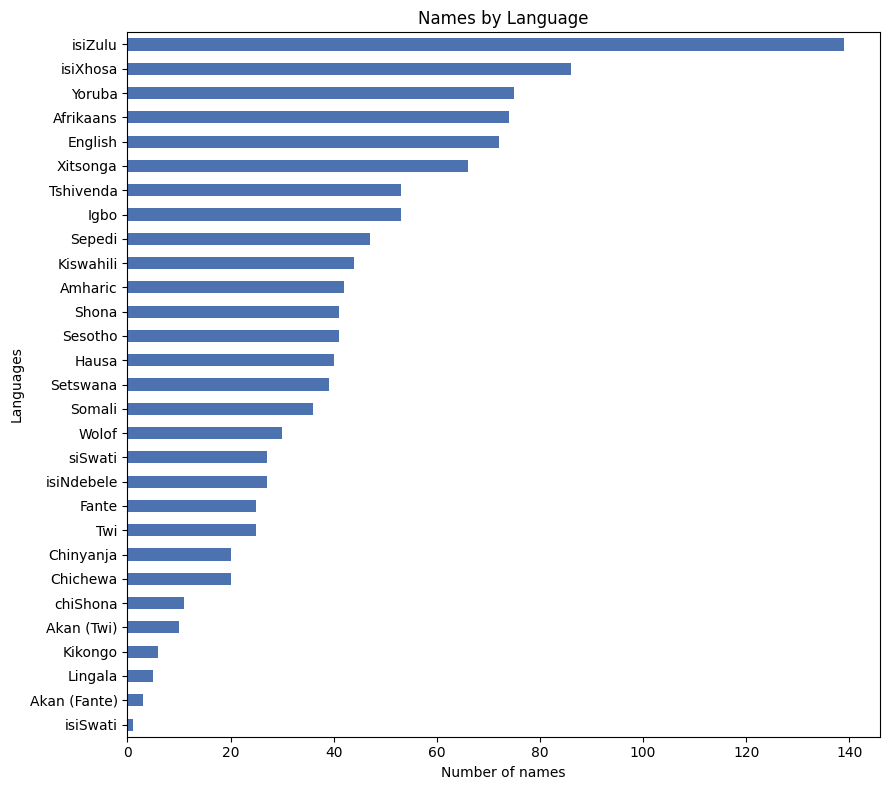

In [ ]:
# this is the graph the shows us the visualised stats from the above regarding the names per language
fig, ax = plt.subplots(figsize=(9,8))
lang_counts.plot(kind='barh', ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_xlabel('Number of names')
ax.set_title('Names by Language')
plt.tight_layout()
plt.show()

## Names by cultural group / tribe

In [ ]:
# names per culutral/tribe group
group_counts = df['Cultural group/tribe'].value_counts()
group_counts

,count
Cultural group/tribe,
Zulu,113
Xhosa,78
Yoruba,75
Afrikaner,74
South African English speakers,71
Vatsonga,66
Igbo,53
Vhavenda,53
Shona,52


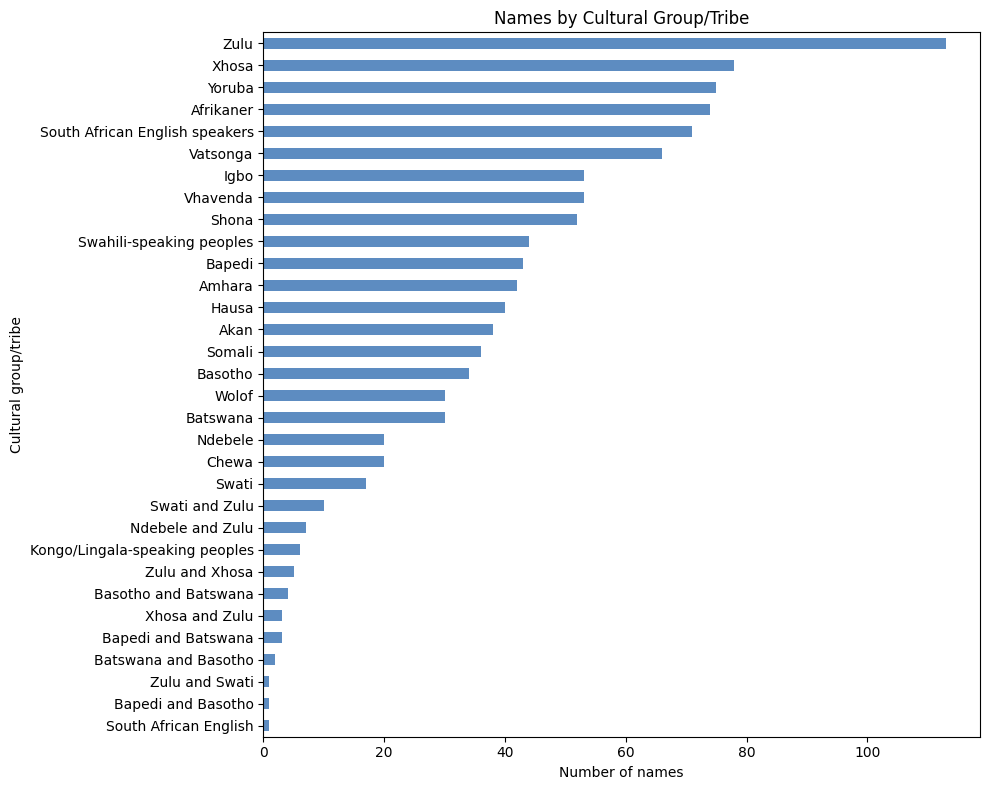

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))
group_counts.plot(kind='barh', ax=ax, color='#5D8CC1')
ax.invert_yaxis()
ax.set_xlabel('Number of names')
ax.set_title('Names by Cultural Group/Tribe')
plt.tight_layout()
plt.show()

## Gender distribution

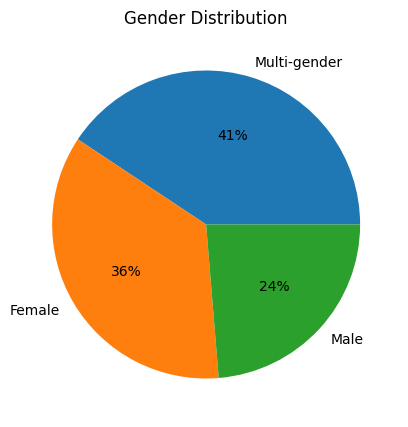

In [ ]:
gender_counts = df['Gender'].value_counts()
fig, ax = plt.subplots(figsize=(5,5))
gender_counts.plot(kind='pie', autopct='%1.0f%%', ax=ax)
ax.set_ylabel('')
ax.set_title('Gender Distribution')
plt.show()

## Data quality check
Look for near-duplicate language labels caused by inconsistent casing/spelling (e.g. `isiSwati` vs `siSwati`).

In [ ]:
from difflib import SequenceMatcher
labels = lang_counts.index.tolist()
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        a, b = labels[i], labels[j]
        if SequenceMatcher(None, a.lower(), b.lower()).ratio() > 0.8:
            print(f'Possible duplicate: "{a}" ({lang_counts[a]}) vs "{b}" ({lang_counts[b]})')

Possible duplicate: "siSwati" (27) vs "isiSwati" (1)
